In [1]:
import cu_rsc as cr
cr.setup_tables()
import numpy as np
import cupy as cp
import cupyx
import matplotlib.pyplot as plt
from tqdm import tqdm
M_dev = cr.load_m_table_device()        # upload to GPU
res   = cr.resources_from_config(M_dev)

### Check optimization result for pulse order

### Old

In [11]:
seq_ref = np.load("seq_cap_0406.npy")

Raman pulses: 100%|██████████| 260/260 [00:19<00:00, 13.36it/s]


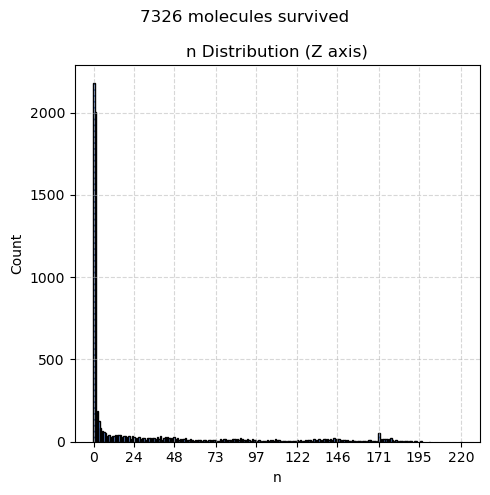

Survival rate: 0.73±1.39e-04
n_bar X: 1.68±1.92e-03
n_bar Y: 2.61±2.76e-03
n_bar Z: 27.86±1.81e-02
fraction of n_{x,y}=0,n_z=0,1: 0.3597


In [47]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)
cr.raman_cool_with_pumping(mol_0, seq_ref, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
print(f"Survival rate: {result["survival_rate_mean"]:.2f}\u00B1{result["survival_rate_sem"]:.2e}")
print(f"n_bar X: {result["mot_mean"][0]:.2f}\u00B1{result["mot_sem"][0]:.2e}")
print(f"n_bar Y: {result["mot_mean"][1]:.2f}\u00B1{result["mot_sem"][1]:.2e}")
print(f"n_bar Z: {result["mot_mean"][2]:.2f}\u00B1{result["mot_sem"][2]:.2e}")
count = np.sum((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))
print(r"fraction of n_{x,y}=0,n_z=0,1:", count/mol_0.shape[0])

### New

In [4]:
seq_op = np.load("../../new_sequence_optimization/op_pulse_order/block_varlen_ga_runs/BlockVarLenGA_20260406_092430/final_top5/top1_sequence.npy")

Raman pulses: 100%|██████████| 196/196 [00:14<00:00, 13.36it/s]


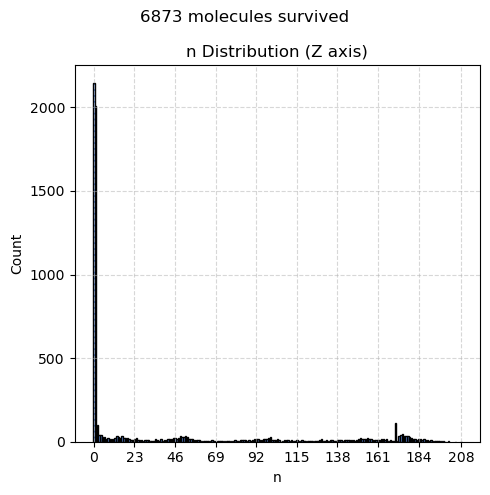

Survival rate: 0.69±1.47e-04
n_bar X: 0.85±1.34e-03
n_bar Y: 1.11±1.82e-03
n_bar Z: 37.06±2.26e-02
fraction of n_{x,y}=0,n_z=0,1: 0.3925


In [49]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)
cr.raman_cool_with_pumping(mol_0, seq_op, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
print(f"Survival rate: {result["survival_rate_mean"]:.2f}\u00B1{result["survival_rate_sem"]:.2e}")
print(f"n_bar X: {result["mot_mean"][0]:.2f}\u00B1{result["mot_sem"][0]:.2e}")
print(f"n_bar Y: {result["mot_mean"][1]:.2f}\u00B1{result["mot_sem"][1]:.2e}")
print(f"n_bar Z: {result["mot_mean"][2]:.2f}\u00B1{result["mot_sem"][2]:.2e}")
count = np.sum((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))
print(r"fraction of n_{x,y}=0,n_z=0,1:", count/mol_0.shape[0])

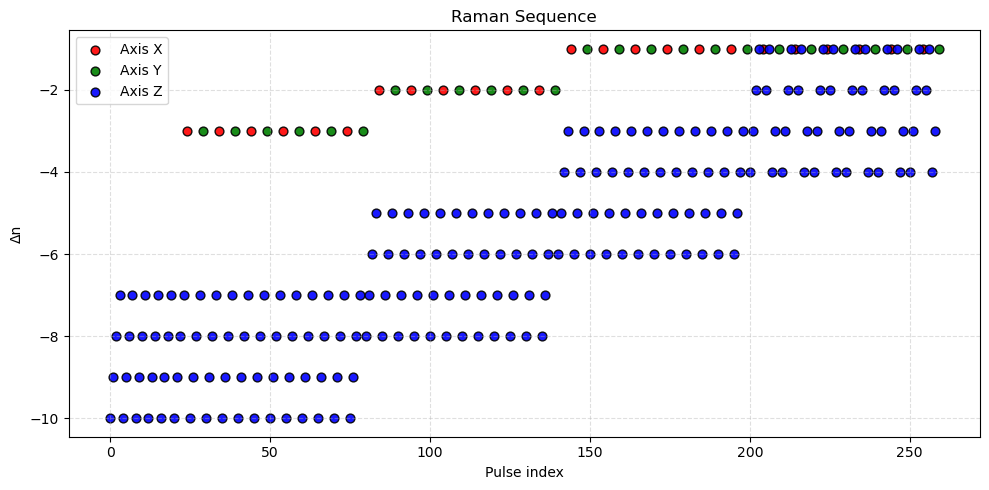

In [13]:
cr.visualize_sequence(seq_ref)

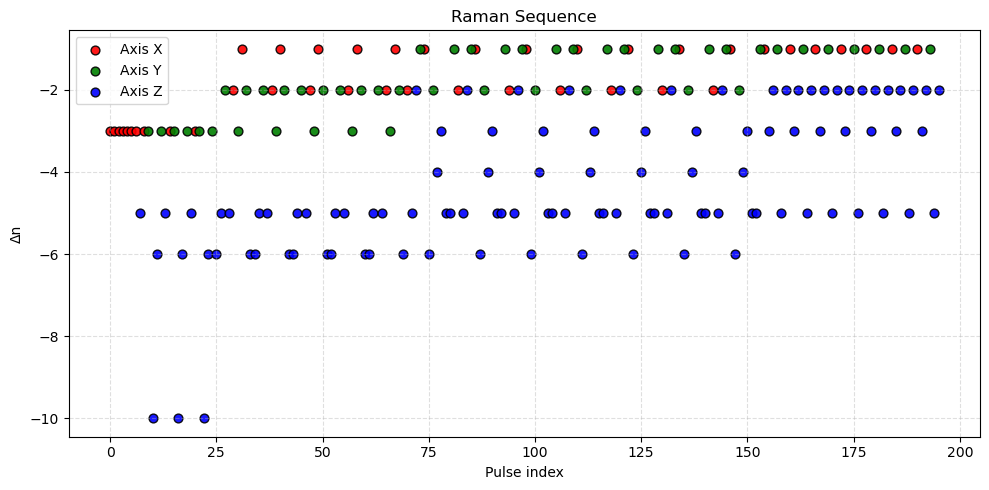

In [14]:
cr.visualize_sequence(seq_op)

### Trimming

In [2]:
import numpy as np

def get_sequence_block(indices, repeats, seq_list):
    block = seq_list[indices]
    return np.tile(block, (repeats, 1))

def build_sequence(block_specs, seq_list):
    blocks = [
        get_sequence_block(indices, repeats, seq_list)
        for indices, repeats in block_specs
    ]
    return np.vstack(blocks)


def rows_to_indices(seq_cap, seq_list, atol=1e-12, rtol=1e-9):
    """
    Convert each row in seq_cap into the matching row index in seq_list.
    """
    indices = []

    for row in seq_cap:
        matches = np.where(
            np.all(np.isclose(seq_list, row, atol=atol, rtol=rtol), axis=1)
        )[0]

        if len(matches) == 0:
            raise ValueError(f"No match found in seq_list for row:\n{row}")
        if len(matches) > 1:
            raise ValueError(f"Ambiguous match for row:\n{row}\nMatches: {matches}")

        indices.append(matches[0])

    return np.array(indices, dtype=int)


def compress_indices_to_blocks(indices):
    """
    Compress an index sequence into block_specs = [(pattern, repeats), ...]
    """
    indices = np.asarray(indices, dtype=int)
    n = len(indices)
    block_specs = []
    i = 0

    while i < n:
        best_pattern = None
        best_repeats = 1
        best_score = 1

        max_pat_len = (n - i) // 2
        for pat_len in range(1, max_pat_len + 1):
            pattern = indices[i:i + pat_len]
            repeats = 1

            while i + (repeats + 1) * pat_len <= n:
                next_chunk = indices[i + repeats * pat_len : i + (repeats + 1) * pat_len]
                if np.array_equal(next_chunk, pattern):
                    repeats += 1
                else:
                    break

            score = pat_len * repeats
            if repeats > 1 and score > best_score:
                best_pattern = pattern
                best_repeats = repeats
                best_score = score

        if best_pattern is not None:
            block_specs.append((best_pattern.copy(), best_repeats))
            i += len(best_pattern) * best_repeats
        else:
            block_specs.append((np.array([indices[i]]), 1))
            i += 1

    return block_specs


def reverse_engineer_blocks(seq_cap, seq_list, atol=1e-12, rtol=1e-9):
    """
    Full pipeline:
    seq_cap -> index sequence -> block_specs
    """
    indices = rows_to_indices(seq_cap, seq_list, atol=atol, rtol=rtol)
    block_specs = compress_indices_to_blocks(indices)
    return indices, block_specs


def seq_row_to_token(row, axis_map=None):
    """
    Convert one seq_list row (axis, delta_n, rabi_freq, time)
    into experiment token like 'Z10'.
    """
    if axis_map is None:
        axis_map = {0: "X", 1: "Y", 2: "Z"}

    axis_id = int(round(row[0]))
    delta_n = int(round(row[1]))

    if axis_id not in axis_map:
        raise ValueError(f"Unknown axis id {axis_id}. axis_map={axis_map}")

    axis = axis_map[axis_id]

    # Your experiment notation uses positive number after the axis
    # for negative delta_n, e.g. delta_n = -10 -> 'Z10'
    if delta_n < 0:
        return f"{axis}{abs(delta_n)}"
    elif delta_n > 0:
        return f"{axis}{delta_n}"
    else:
        return f"{axis}0"


def pattern_indices_to_experiment_string(indices, seq_list, axis_map=None, op_token="OP"):
    """
    Convert a block pattern given by seq_list indices into string like:
    'Z10,OP,Z9,OP,Z8,OP'
    """
    tokens = []
    for idx in indices:
        token = seq_row_to_token(seq_list[idx], axis_map=axis_map)
        tokens.extend([token, op_token])
    return ",".join(tokens)


def block_specs_to_experiment_sequence(block_specs, seq_list, axis_map=None, op_token="OP"):
    """
    Convert block_specs = [(indices, repeats), ...]
    into experiment_sequence = [(repeats, '...'), ...]
    """
    experiment_sequence = []
    for indices, repeats in block_specs:
        seq_str = pattern_indices_to_experiment_string(
            indices, seq_list, axis_map=axis_map, op_token=op_token
        )
        experiment_sequence.append((int(repeats), seq_str))
    return experiment_sequence


def seq_cap_to_experiment_sequence(seq_cap, seq_list, atol=1e-12, rtol=1e-9,
                                   axis_map=None, op_token="OP"):
    """
    Full conversion:
    seq_cap -> indices -> block_specs -> experiment_sequence
    """
    indices, block_specs = reverse_engineer_blocks(seq_cap, seq_list, atol=atol, rtol=rtol)
    experiment_sequence = block_specs_to_experiment_sequence(
        block_specs, seq_list, axis_map=axis_map, op_token=op_token
    )
    return indices, block_specs, experiment_sequence

def print_experiment_sequence(experiment_sequence, var_name="cooling_sequence"):
    print(f"{var_name} = [")
    for repeats, seq_str in experiment_sequence:
        print(f'    ({repeats}, "{seq_str}"),')
    print("]")

In [3]:
seq_list = np.load("seq_list_0406.npy")

In [52]:
seq_list

array([[ 0.00000000e+00, -3.00000000e+00,  1.84187616e+04,
         7.63928164e-05],
       [ 0.00000000e+00, -2.00000000e+00,  1.45368382e+04,
         9.39173207e-05],
       [ 0.00000000e+00, -1.00000000e+00,  7.84287242e+03,
         1.34476841e-04],
       [ 1.00000000e+00, -3.00000000e+00,  1.85722610e+04,
         7.00206985e-05],
       [ 1.00000000e+00, -2.00000000e+00,  1.18053453e+04,
         1.04600718e-04],
       [ 1.00000000e+00, -1.00000000e+00,  5.65819742e+03,
         1.58817067e-04],
       [ 2.00000000e+00, -1.00000000e+01,  1.00000000e+04,
         2.66231928e-05],
       [ 2.00000000e+00, -9.00000000e+00,  1.00000000e+04,
         4.27740350e-05],
       [ 2.00000000e+00, -8.00000000e+00,  1.00000000e+04,
         4.10213287e-05],
       [ 2.00000000e+00, -7.00000000e+00,  1.00000000e+04,
         2.18312536e-05],
       [ 2.00000000e+00, -6.00000000e+00,  1.00000000e+04,
         4.91887879e-05],
       [ 2.00000000e+00, -5.00000000e+00,  1.00000000e+04,
      

In [5]:
indices, block_specs = reverse_engineer_blocks(seq_op, seq_list)

print(indices)
for k, (pattern, repeats) in enumerate(block_specs, 1):
    print(f"block_{k} = get_sequence_block(np.array({pattern.tolist()}), {repeats}, seq_list)")

[ 0  0  0  0  0  0  0 11  0  3  6 10  3 11  0  3  6 10  3 11  0  3  6 10
  3 10 11  4 11  1  3  2  4 10 10 11  4 11  1  3  2  4 10 10 11  4 11  1
  3  2  4 10 10 11  4 11  1  3  2  4 10 10 11  4 11  1  3  2  4 10  1 11
 14  5  2 10  4 12 13 11 11  5  1 11 14  5  2 10  4 12 13 11 11  5  1 11
 14  5  2 10  4 12 13 11 11  5  1 11 14  5  2 10  4 12 13 11 11  5  1 11
 14  5  2 10  4 12 13 11 11  5  1 11 14  5  2 10  4 12 13 11 11  5  1 11
 14  5  2 10  4 12 13 11 11  5  2 13 14  5 11 14  2 13 14  5 11 14  2 13
 14  5 11 14  2 13 14  5 11 14  2 13 14  5 11 14  2 13 14  5 11 14  2 13
 14  5 11 14]
block_1 = get_sequence_block(np.array([0]), 7, seq_list)
block_2 = get_sequence_block(np.array([11, 0, 3, 6, 10, 3]), 3, seq_list)
block_3 = get_sequence_block(np.array([10, 11, 4, 11, 1, 3, 2, 4, 10]), 5, seq_list)
block_4 = get_sequence_block(np.array([1, 11, 14, 5, 2, 10, 4, 12, 13, 11, 11, 5]), 7, seq_list)
block_5 = get_sequence_block(np.array([2, 13, 14, 5, 11, 14]), 7, seq_list)


In [6]:
block_2 = get_sequence_block(np.array([11, 0, 3, 10, 0, 3]), 3, seq_list)
block_3 = get_sequence_block(np.array([10, 11, 4, 11, 1, 3, 2, 4, 10]), 5, seq_list)
block_4 = get_sequence_block(np.array([1, 11, 14, 5, 2, 10, 4, 12, 13, 11, 11, 5]), 7, seq_list)
block_5 = get_sequence_block(np.array([2, 13, 14, 5, 11, 14]), 7, seq_list)

seq_trim = np.vstack([block_2, block_3, block_4, block_5])

Raman pulses: 100%|██████████| 189/189 [00:14<00:00, 13.27it/s]


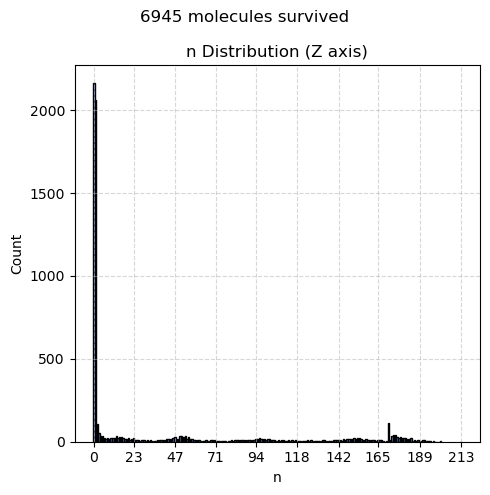

Survival rate: 0.69±1.42e-04
n_bar X: 0.89±1.40e-03
n_bar Y: 0.95±1.58e-03
n_bar Z: 35.95±2.20e-02
fraction of n_{x,y}=0,n_z=0,1: 0.4011


In [7]:
temp = [25e-6, 25e-6, 25e-6]
mol_0 = cr.build_thermal_molecules(10000, temp)
cr.raman_cool_with_pumping(mol_0, seq_trim, res, show_progress=True)
dist = cr.get_n_distribution_gpu(mol_0, max_bins=10, plot=(False, False, True))
result = cr.bootstrap_stats_from_molecules(mol_0)
print(f"Survival rate: {result["survival_rate_mean"]:.2f}\u00B1{result["survival_rate_sem"]:.2e}")
print(f"n_bar X: {result["mot_mean"][0]:.2f}\u00B1{result["mot_sem"][0]:.2e}")
print(f"n_bar Y: {result["mot_mean"][1]:.2f}\u00B1{result["mot_sem"][1]:.2e}")
print(f"n_bar Z: {result["mot_mean"][2]:.2f}\u00B1{result["mot_sem"][2]:.2e}")
count = np.sum((mol_0[:, 0] == 0) & (mol_0[:, 1] == 0) & (mol_0[:, 2] <= 1))
print(r"fraction of n_{x,y}=0,n_z=0,1:", count/mol_0.shape[0])

In [8]:
np.save("seq_op.npy", seq_trim)

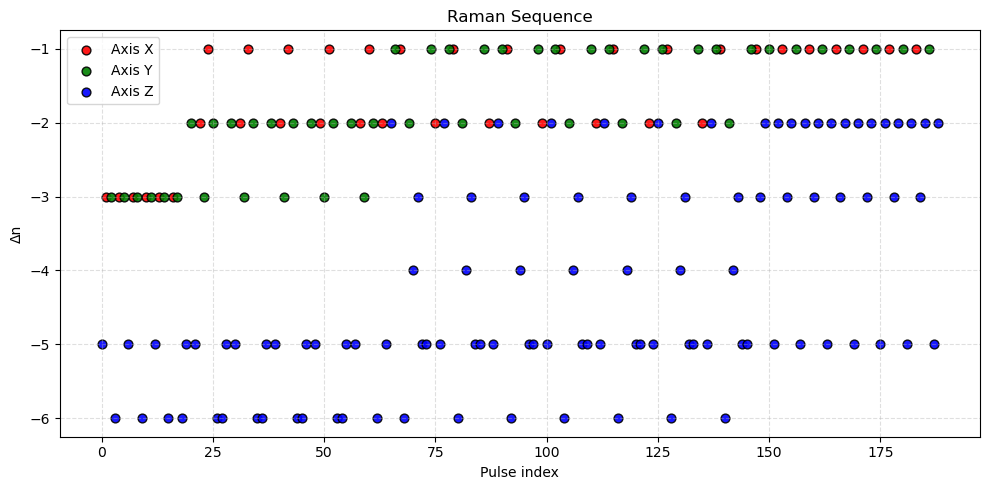

In [62]:
cr.visualize_sequence(seq_trim)

In [30]:
189/260

0.7269230769230769

### Convert to experiment

In [63]:
indices, block_specs_recovered, experiment_sequence_recovered = seq_cap_to_experiment_sequence(
    seq_trim, seq_list
)

print("Recovered indices:")
print(indices)

print("\nRecovered block specs:")
for pattern, repeats in block_specs_recovered:
    print(repeats, pattern)

print("\nExperiment sequence:")
for item in experiment_sequence_recovered:
    print(item)

Recovered indices:
[11  0  3 10  0  3 11  0  3 10  0  3 11  0  3 10  0  3 10 11  4 11  1  3
  2  4 10 10 11  4 11  1  3  2  4 10 10 11  4 11  1  3  2  4 10 10 11  4
 11  1  3  2  4 10 10 11  4 11  1  3  2  4 10  1 11 14  5  2 10  4 12 13
 11 11  5  1 11 14  5  2 10  4 12 13 11 11  5  1 11 14  5  2 10  4 12 13
 11 11  5  1 11 14  5  2 10  4 12 13 11 11  5  1 11 14  5  2 10  4 12 13
 11 11  5  1 11 14  5  2 10  4 12 13 11 11  5  1 11 14  5  2 10  4 12 13
 11 11  5  2 13 14  5 11 14  2 13 14  5 11 14  2 13 14  5 11 14  2 13 14
  5 11 14  2 13 14  5 11 14  2 13 14  5 11 14  2 13 14  5 11 14]

Recovered block specs:
3 [11  0  3 10  0  3]
5 [10 11  4 11  1  3  2  4 10]
7 [ 1 11 14  5  2 10  4 12 13 11 11  5]
7 [ 2 13 14  5 11 14]

Experiment sequence:
(3, 'Z5,OP,X3,OP,Y3,OP,Z6,OP,X3,OP,Y3,OP')
(5, 'Z6,OP,Z5,OP,Y2,OP,Z5,OP,X2,OP,Y3,OP,X1,OP,Y2,OP,Z6,OP')
(7, 'X2,OP,Z5,OP,Z2,OP,Y1,OP,X1,OP,Z6,OP,Y2,OP,Z4,OP,Z3,OP,Z5,OP,Z5,OP,Y1,OP')
(7, 'X1,OP,Z3,OP,Z2,OP,Y1,OP,Z5,OP,Z2,OP')
